# Decision Tree Worksheet

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import graphviz
import matplotlib.pyplot as plt

## Loading data

Load Pima diabetes dataset and split data, with test size 20% and validaton 20%.

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

## YOUR CODE HERE
data = pd.read_csv(url, names=names)

# Dropping NaN rows
invalid = ['plas', 'pres', 'skin', 'test', 'mass']

for i in invalid:
    data[i].replace(to_replace=0, value=np.nan, inplace=True)

data = data.dropna(axis=0).reset_index(drop=True)
data.head()

# Splitting data
X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
y_col = 'class'

test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size=test_size, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=0)

/tmp/ipykernel_732/3442244639.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].replace(to_replace=0, value=np.nan, inplace=True)


## Creating Model

Make a model using sklearn's DecisionTreeClassifier, with a high max-depth and low minimum sample leafs.

In [4]:
## YOUR CODE HERE
decision_tree = DecisionTreeClassifier(max_depth=100, min_samples_leaf=5)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=100, min_samples_leaf=5)

Print accuracy of training and validation data.

In [5]:
## YOUR CODE HERE
y_train_pred=decision_tree.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=decision_tree.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  90.4
Validation Accuracy is  71.42857142857143


Make a model with a low max-depth and higher minimum sample leafs.

In [15]:
## YOUR CODE HERE
model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10)

Print accuracy of training and validation data.

In [8]:
## YOUR CODE HERE
y_train_pred=decision_tree.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=decision_tree.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  74.0
Validation Accuracy is  73.01587301587301


Explain the accuracy results below.

(Since the max depth of the first model is bigger, the training accuracy is better, but it is overfitting it more, leading to less validation accuracy.)

## Metrics

Plot the ROC curve and print the AUC of the second model.

0.8244565217391304


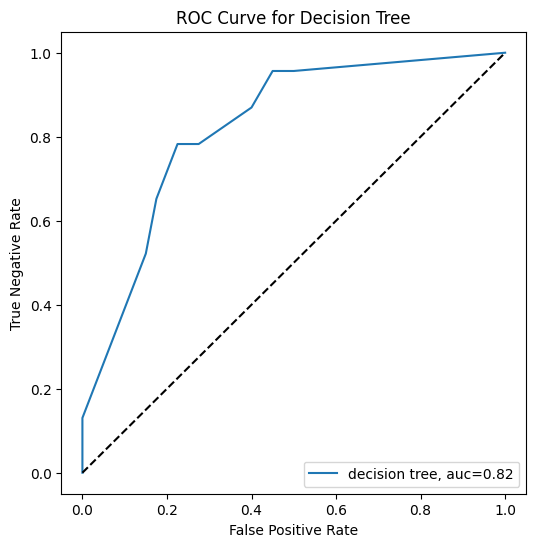

In [37]:
## YOUR CODE HERE
y_pred_proba = model.predict_proba(X_val)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_val,  y_pred_proba)
auc = metrics.roc_auc_score(y_val, y_pred_proba)
print(auc)

plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,label=f"decision tree, auc={auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Negative Rate')
plt.legend(loc=4)
plt.show()


Use graphviz to visualize your 2nd tree.

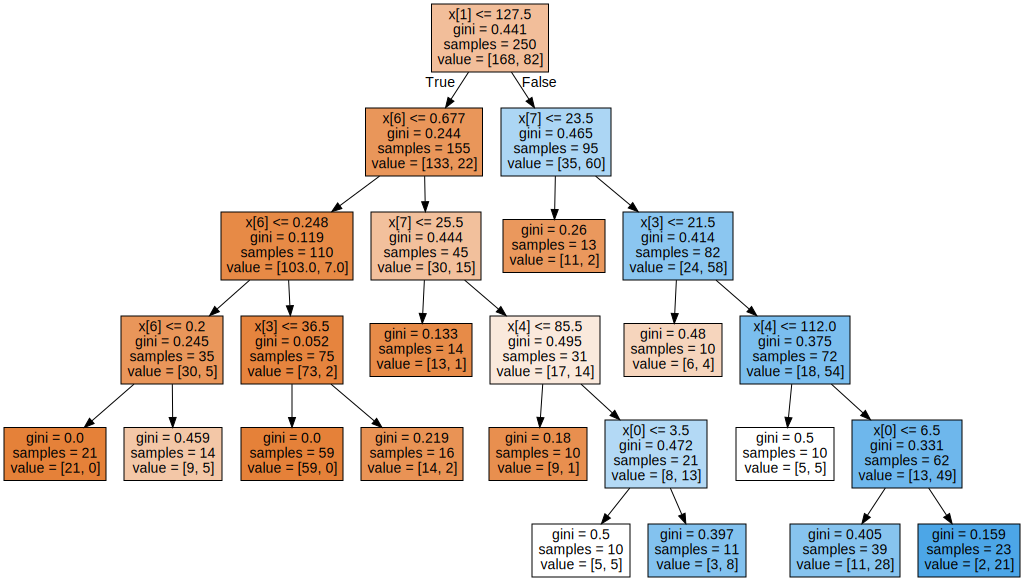

In [18]:
## YOUR CODE HERE
dot_data = tree.export_graphviz(model, out_file=None, filled=True)

graph = graphviz.Source(dot_data)
graph

#### Use the graph above to answer the questions below

Question 1: What do you think X[n] represents in the nodes from the graph?

(x[n] represents the features)



Question 2: What is the root feature? Does it make sense as the root feature?

(The root feature is plas, which makes sense because blood glucose level determines diabetes)



Question 3: If you were to change the parameters to have a max_depth of 500 and min_samples_leaf of 1, what do you think the effect would be on the test accuracy? Training accuracy?

(The training accuracy would be very high, but test accuracy would be very low)


**Test your guesses, create a model with max_depth=500 and min_samples_leaf=1, and predict values for the training and validation data**

In [25]:
## YOUR CODE HERE
model_guess_test = DecisionTreeClassifier(max_depth=500, min_samples_leaf=1)
model_guess_test.fit(X_train, y_train)

train_pred_guess = model_guess_test.predict(X_train)
val_pred_guess = model_guess_test.predict(X_test)

print(accuracy_score(y_train, train_pred_guess)*100)
print(accuracy_score(y_test, val_pred_guess)*100)


100.0
78.48101265822784


# Random Forest

## Creating Model

Create a model with sklearn's RandomForestClassifier and predict values on your validation set.

In [27]:
## YOUR CODE HERE
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, y_train)

RandomForestClassifier()

Print accuracy of training and validation data.

In [28]:
## YOUR CODE HERE
y_train_pred=random_forest.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=random_forest.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  100.0
Validation Accuracy is  82.53968253968253


How did the accuracy compare to the decision tree's accuracy?

(The training and validation accuracies were higher)



Print the 3 most important features (hint: sklearn has an attribute to help you find these)

In [30]:
## YOUR CODE HERE
feature_importances = pd.Series(random_forest.feature_importances_, index=names[:-1]).sort_values(ascending=False)
print("\ntop 3 most important features:")
print(feature_importances.head(3))


top 3 most important features:
plas    0.248118
test    0.153953
age     0.124869
dtype: float64


Find the accuracy for random forests with 1 to 100 trees, counting by 5. Print and then plot these accuracies.

trees: 1, Accuracy: 63.29%
trees: 6, Accuracy: 79.75%
trees: 11, Accuracy: 83.54%
trees: 16, Accuracy: 81.01%
trees: 21, Accuracy: 82.28%
trees: 26, Accuracy: 81.01%
trees: 31, Accuracy: 79.75%
trees: 36, Accuracy: 77.22%
trees: 41, Accuracy: 75.95%
trees: 46, Accuracy: 77.22%
trees: 51, Accuracy: 78.48%
trees: 56, Accuracy: 78.48%
trees: 61, Accuracy: 79.75%
trees: 66, Accuracy: 78.48%
trees: 71, Accuracy: 78.48%
trees: 76, Accuracy: 78.48%
trees: 81, Accuracy: 78.48%
trees: 86, Accuracy: 77.22%
trees: 91, Accuracy: 77.22%
trees: 96, Accuracy: 77.22%


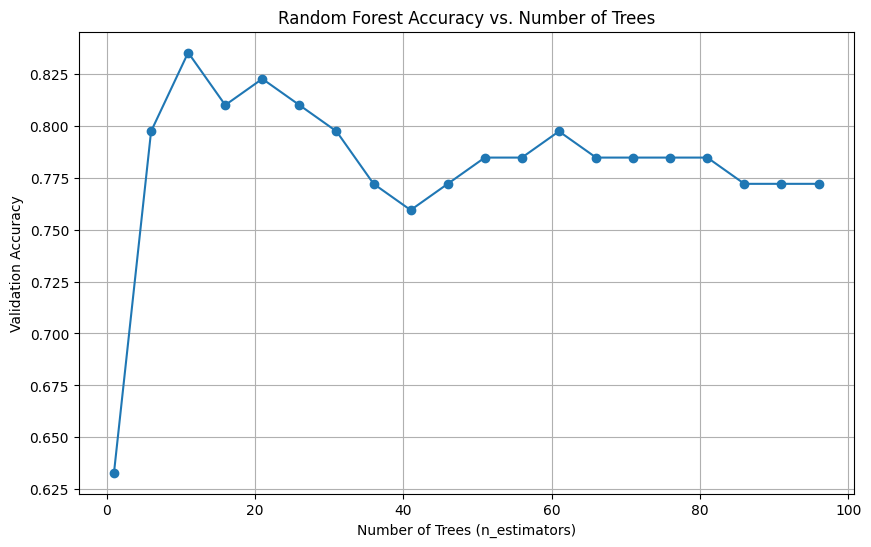

In [39]:
## YOUR CODE HERE
n_estimators_range = range(1, 100, 5)
accuracies = []

for n in n_estimators_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"trees: {n}, Accuracy: {accuracy*100:.2f}%")

plt.figure(figsize=(10,6))
plt.plot(n_estimators_range, accuracies, marker='o')
plt.title('Random Forest Accuracy vs. Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()


Plot the roc_curve using predict_proba a function for our random forest model, and metrics.roc_curve

It might help to google these functions and look at sklearn's documentation.

0.8766304347826087


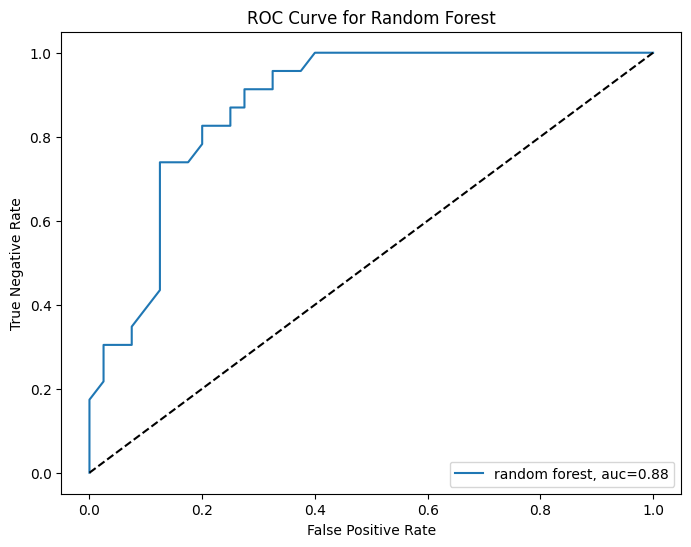

In [36]:
## YOUR CODE HERE
y_pred_proba_random_forest = random_forest.predict_proba(X_val)[:,1]
fpr, tpr, _ = metrics.roc_curve(y_val,  y_pred_proba_random_forest)
auc = metrics.roc_auc_score(y_val, y_pred_proba_random_forest)
print(auc)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"random forest, auc={auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Negative Rate')
plt.legend(loc=4)
plt.show()